# Krusell-Smith Deep-Learning Code Walkthrough (Classroom Short-Run Version)

This annotated version is based on the original reference notebook and is intended for the main part of the tutorial.

Class format: the instructor walks through the main code blocks on the projector, while students run the reduced classroom version in parallel. The KS model is larger than the MMW example. The classroom goal is to understand the structure and tensor dimensions, not to wait for full convergence.

Before running this notebook, students should have followed `01_Setup_and_Run_Guide.md` and completed the first environment check in notebook 02. If imports fail, use the setup guide and the error message to troubleshoot; AI tools can help interpret the error, and unresolved setup issues can be brought to TA Peiyuan Zhang during a break.

Reading path:

```text
heterogeneous-agent states -> neural network -> decisions
Euler equation errors -> objective -> training loop -> simulation / plots
```

Run level: imports, parameters, network structure, and Euler objective are required reading; reduced training can be run briefly; full training and simulation plots are after-class tasks.

During the walkthrough, it is useful to emphasize how the agent dimension, network input/output, and Euler objective correspond to the model equations in the paper.


# Introduction

> Guide: This notebook solves a Krusell-Smith heterogeneous-agent model. It is larger than the previous MMW example. In class, follow the instructor and focus on the structure: model, agent dimension, neural network, Euler objective, training, and simulation.


This notebook solves a version of Krusell and Smith's (1998) heterogenous-agent model with idiosyncrastic and aggregate shocks, incomplete markets and borrowing constraints. It uses a deep learning Euler-equation method introduced by Maliar, Maliar and Winant (2018) in the paper "Deep learning for solving dynamic economic models", Journal of Monetary Economics 122, pp 76-101. https://lmaliar.ws.gc.cuny.edu/files/2021/09/JME2021.pdf

This notebook shows a version of the Euler equation method that minimizes the sum of squared residuals in the equilibrium conditions. See https://deepecon.org for documentation, updates and the other versions of the deep learning method (Bellman equation and life-time reward). 

Copyright (c) 2019-2023 Marc Maliar. All rights reserved.

#### Importing required Python libraries

> Guide: Import TensorFlow, NumPy, Matplotlib, and other dependencies. If this fails, it is usually an environment issue. Check `01_Setup_and_Run_Guide.md`, use AI tools to interpret the error if helpful, or ask TA Peiyuan Zhang during a break.


> Run note: The next code cell imports dependencies and checks the environment. If it fails, check TensorFlow / NumPy / Matplotlib first.


In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import pickle

> Run note: The next code cell imports dependencies and checks the environment. If it fails, check TensorFlow / NumPy / Matplotlib first.


In [25]:
print('tf version:', tf.__version__)

tf version: 2.21.0


> Run note: The next code cell imports dependencies and checks the environment. If it fails, check TensorFlow / NumPy / Matplotlib first.


In [26]:
# Disable GPU, uncomment if you want to use GPU
tf.config.set_visible_devices([], 'GPU')

# Deep learning method

> Guide: This cell sets deep-learning hyperparameters such as the number of agents, learning rate, training steps, and batch size. The classroom default is reduced mode, so students can see the workflow. For the full original run, use `05_KS_Model_Full_Version.ipynb` after class.


In [27]:
# Classroom mode keeps the KS walkthrough runnable during a 90-minute tutorial.
# For the full original reference run, use 05_KS_Model_Full_Version.ipynb.
CLASSROOM_MODE = True

AGENTS = 20 if CLASSROOM_MODE else 50     # number of agents
LEARNING_RATE = 1e-3
TRAINING_STEPS = 500 if CLASSROOM_MODE else 30000
BATCH_SIZE = 5 if CLASSROOM_MODE else 10
DISPLAY_STEP = 100 if CLASSROOM_MODE else 1000
TRAIN_STEP_INTERVAL = 2 # Interval of steps between training episodes

print({
    "CLASSROOM_MODE": CLASSROOM_MODE,
    "AGENTS": AGENTS,
    "TRAINING_STEPS": TRAINING_STEPS,
    "BATCH_SIZE": BATCH_SIZE,
})


{'CLASSROOM_MODE': True, 'AGENTS': 20, 'TRAINING_STEPS': 500, 'BATCH_SIZE': 5}


# Krusell and Smith's (1998) model

The economy consists of a set of heterogeneous agents $i=1,...,\ell $ that
are identical in fundamentals but differ in productivity and capital. Each
agent $i$ solves 
\begin{gather}
\underset{ \{ c_{t}^{i},k_{t+1}^{i} \} _{t=0}^{\infty }}{\max }%
E_{0}[ \sum_{t=0}^{\infty }\beta ^{t}u( {c_{t}^{i}}) ] \\
\text{s.t. }w_{t+1}^{i}=( R_{t+1}-d ) ( w_{t}^{i}-c_{t}^{i})
+W_{t+1}\exp ( y_{t+1}^{i}) , \\
c_{t}^{i}\leq w_{t}^{i},
\end{gather}
where $\beta_{t}$,$c_{t}^{i}$, $w_{t}^{i}$, $y_{t}^{i}$, $R_{t}$, $W_{t}$ and $%
k_{t+1}^{i}=w_{t}^{i}-c_{t}^{i}$ are time preference, consumption, cash-on-hand, labor
productivity, interest rate, wage and next-period capital, respectively. $d\in
( 0,1] $ is the depreciation rate.
Initial condition $( y_{0}^{i},w_{0}^{i}) $ is given. The
individual productivity evolves as 
\begin{equation}
y_{t+1}^{i}=\rho _{y}y_{t}^{i}+\sigma _{y}\epsilon _{t}^{i}\text{ with }
\epsilon _{t}^{i}\sim \mathcal{N}( 0,1) .
\end{equation}
The production side of the economy is described by a Cobb-Douglas production
function $z_{t}Ak_{t}^{\alpha }[ \sum_{i=1}^{\ell }\exp (
y_{t}^{i}) ]$, where A is technology level, $\alpha \in ( 0,1) $ and $%
z_{t}$ is an aggregate productivity shock, 
\begin{equation}
z_{t+1}=\rho_{z} z_{t}+\sigma_{z} \epsilon _{t}\text{ with }\epsilon _{t}\sim 
\mathcal{N}( 0,1) .
\end{equation}
Initial condition $z_{0}$ is given. The equilibrium prices are

\begin{equation}
R_{t}=
1+z_{t}\alpha Ak_{t}^{\alpha -1}[ \sum_{i=1}^{\ell}\exp (
y_{t}^{i}) ] \text{ and }W_{t}=z_{t}( 1-\alpha )A
k_{t}^{\alpha }[ \sum_{i=1}^{\ell }\exp ( y_{t}^{i}) ], 
\end{equation}


where $k_{t}=\sum_{i=1}^{\ell }k_{t}^{i}$ is aggregate capita. Note that $w_{t}^{i}=R_{t}k_{t}^{i}+W_{t}\exp ( y_{t}^{i}) $. In the benchmark case, we
parametrize the model by CRRA utiltiy function, $u( c) =\frac{c^{1-\gamma }-1}{1-\gamma }
$, with a risk-aversion coefficient of $\gamma =1$. This means that the utility function is $u( c)=\ln(c)$.
We assume d=0.08, $\beta =0.96$, $%
\rho_{z} =0.95$, $\sigma_{z} =0.01$, $\rho _{y}=0.9$, and $\sigma _{y}=0.2(
1-\rho _{y}^{2}) ^{1/2}$.


> Guide: The KS model definition starts here. Focus on how state variables, individual heterogeneity, and aggregate shocks enter the code.


# Preliminaries

> Guide: Preliminaries: parameters, steady state, and helper functions.


#### Model parameters

> Guide: Model parameters determine preferences, production, and shock processes.


In [28]:
α = 0.36   # share of capital in the Cobb-Douglas production function
d = 0.08   # depreciation rate 
A = 1      # Technology level
β = 0.96   # Time preferece/discount factor
γ = 1      # parameter for risk aversion. CRRA utility function. 
d = 0.08

mean_z = 0.0    # aggregate productivity shock
ρ_z = 0.9    # persistency of aggregate productivity shock
σ_z = 0.01   # standard deviation

mean_y = 0.0 # idiosyncratic productivity shock
ρ_y = 0.95   #persistency of idiosyncratic productivity shock
σ_y = 0.2    # standard deviation

#### Steady state

In [29]:
K_STEADY_STATE = (((1/β)-(1-d))/α/A)**(1/(α-1))           # capital
W_STEADY_STATE = K_STEADY_STATE*(1-d)+A*K_STEADY_STATE**α # wealth 
C_STEADY_STATE = A*K_STEADY_STATE**α-d*K_STEADY_STATE     # consumption
ξ_STEADY_STATE = C_STEADY_STATE/W_STEADY_STATE            # consumption-to-wealth ratio, ksi

## Stochastic solution domain

Our economy has 2*AGENTS + 1 state variables, which are wealth and productivity of all agents and an aggregate productivity. Our DL framework solves the model on stochastic simulation (ergodic set). When simulating the model, we: 
- restrict aggregate and individual productivities $z, y$ to be within ± 2*standard deviations $\frac{±\sigma}{\sqrt{1-\rho^2}}$;
- restrict $w$ to be within an interval: $w\in[w_{\min}, w_{\max}]$.

> Guide: Stochastic solution domain. Training samples states from these ranges.


#### Bounds on state variables

In [30]:
# Bounds for aggregate productivity level
z_min = math.exp(-2 * σ_z  / math.sqrt(1-ρ_z**2))
z_max = math.exp(2 * σ_z  / math.sqrt(1-ρ_z**2))

# Bounds for individual productivity level
y_min = math.exp(-2 * σ_y  / math.sqrt(1-ρ_y**2))
y_max = math.exp( 2 * σ_y  / math.sqrt(1-ρ_y**2))

# Cash-on-hand's bounds
w_min = 0.0*W_STEADY_STATE
w_max = 4.0*W_STEADY_STATE

#### Model functions

> Guide: Model functions such as consumption, capital, and prices. The residual calculation calls these functions repeatedly.


In [31]:
def mean_across_agents(x):
    return tf.reduce_mean(x, axis=1, keepdims=True)

def consumption_capital(w, ξ):
    c = w*ξ
    kp = w*(1-ξ)                    # k' = next-period indovodual capital
    kp = tf.math.minimum(kp, w_max) # if kp>W_HIGH, set kp=W_HIGH
    c = w - kp                      # recompute c 
   
    return c, kp

def next_period(kp, yp, zp):
    kp_aggregate = mean_across_agents(kp)
    rp = A*zp*α*kp_aggregate**(α-1)      # next-period interest rate
    wagep = A*zp*(1-α)*kp_aggregate**(α) # next-period wage
    wp = (1-d+rp)*kp+wagep*yp            # individual next-period wealth
    
    return rp, wp

def productivity_transition_to_next_period(y, z, εy, εz):
    yp = y**ρ_y*tf.math.exp(εy)*math.exp((-0.5*(1-ρ_y)*σ_y**2)/(1-ρ_y**2))
        # exp((-0.5*(1-ρ_y)*σ_y**2)/(1-ρ_y**2)) makes mean = 1
    yp = tf.math.minimum(tf.math.maximum(yp, y_min), y_max)
        # restrict the individual productivity to be within the bounds
    yp = yp / mean_across_agents(yp)
        # normalize future individual shocks so that they sum up to one 
    
    zp = z**ρ_z*tf.math.exp(εz)*math.exp((-0.5*(1-ρ_z)*σ_z**2)/(1-ρ_z**2))
    zp = tf.math.minimum(tf.math.maximum(zp, z_min), z_max)
        # the same for aggregare productivity except of normalizing to one
    return yp, zp 

def normalize_all(w, y, z):                                # normalize inputs for neural network
    normw = (w - w_min) / (w_max-w_min)*2.0 - 1.0          # normalize to interval [-1,1]
    normy = tf.math.log(y) / (2*σ_y / math.sqrt(1-ρ_y**2)) # normalize to ±2standard deviations to approximately fit to [-1,1]
    normz = tf.math.log(z) / (2*σ_z / math.sqrt(1-ρ_z**2)) 
    
    return normw, normy, normz

# The neural-network

> Guide: Neural-network section. The network approximates decision rules in a high-dimensional state space.


#### Parameterization of decision functions with neural networks

> Guide: This explains how the neural network represents decision functions.


We parametrize the consumption to
wealth ratio $\frac{c_{t}^{i}}{w_{t}^{i}}$ and unit-free Lagrange multiplier $%
h_{t}^{i}$:
$$
\begin{aligned}
\xi_t=\frac{c_{t}^{i}}{w_{t}^{i}} &=\sigma ( \zeta _{0}+\eta (
y_{t}^{i},w_{t}^{i},D_{t},z_{t};\vartheta ) ) \equiv \varphi
( \cdot ;\theta ), \\
h_{t}^{i} &=\exp ( \zeta _{0}+\eta (
y_{t}^{i},w_{t}^{i},D_{t},z_{t};\vartheta ) ) \equiv h(
\cdot ;\theta ), 
\end{aligned}
$$
where $\eta ( \cdot ;\vartheta ) $ is a neural network, $%
D_{t}\equiv  \{ y_{t}^{i},w_{t}^{i} \} _{i=1}^{\ell }$ is the
distribution, $\theta \equiv ( \zeta _{0},\vartheta ) $ and $%
\sigma ( x) =\frac{1}{1+e^{-x}}$.

A sigmoid transformation of $\varphi ( \cdot ;\theta ) $ ensures
that $\frac{c_{t}^{i}}{w_{t}^{i}}$ is in the interval $[ 0,1] $;
the exponentiation of $h_{t}$ ensures that it is nonnegative. The parameter $%
\zeta _{0}$s are calibrated; $\zeta _{0}=logit(\frac{c_{steady\_state}}{w_{steady\_state}})$ for $\varphi
( \cdot ;\theta )$ and $\zeta _{0}=0$ for $h(
\cdot ;\theta )$.
The biases and weights are initialized
randomly by using "he" and "glorot" uniform distributions,
respectively. In the baseline case, we use a neural network with a sigmoid
activation function and two hidden layers of $32\times 32$ neurons.

#### Architecture

> Guide: Network architecture: layers, hidden units, input dimension, and output dimension.


In [32]:
input_dimension = 2*AGENTS+3           # inputs consist of 
                                       # 2*AGENTS state variables of all agents 
                                       # 2 state variables of a given agent i (wealth and productivities)
                                       # 1 aggregate productivity 
first_hidden_layer_neurons = 32
second_hidden_layer_neurons = 32
output_dimension = 2                   # ksi (share of consumption in wealth), multiplier (on the borrowing constraint)

#### Resulting layer shapes (weights and biases)

In [33]:
first_hidden_layer_weights_shape = \
    (input_dimension,             first_hidden_layer_neurons)
# E.g., with 10 agents and 4 neurons, it's 23-by-4, where input_dimension = 23 with 10 agents
first_hidden_layer_biases_shape  = \
    (1,                           first_hidden_layer_neurons)

second_hidden_layer_weights_shape = \
    (first_hidden_layer_neurons,  second_hidden_layer_neurons)
# E.g., 4 neurons in each hidden leayer, it's 4-by-4
second_hidden_layer_biases_shape  = \
    (1,                           second_hidden_layer_neurons)

output_layer_weights_shape = \
    (second_hidden_layer_neurons, output_dimension)
output_layer_biases_shape  = \
    (1,                           output_dimension)

#### Creating the neural-network weights in TensorFlow

> Guide: Neural-network weights are created manually. This notebook does not rely fully on Keras Sequential; it writes the weight matrices explicitly.


In [34]:
# Weights initializers
he_normal_initializer = tf.keras.initializers.he_normal()
zero_initializer = tf.keras.initializers.Constant(value=0.0)
small_initializer = tf.keras.initializers.TruncatedNormal(mean=0.0, stddev=0.01)

first_hidden_layer_weights = \
    tf.compat.v1.get_variable(name = "first_hidden_layer_weights", 
                              shape=first_hidden_layer_weights_shape, 
                              initializer=small_initializer)

first_hidden_layer_biases = \
    tf.compat.v1.get_variable(name = "first_hidden_layer_biases", 
                              shape=first_hidden_layer_biases_shape, 
                              initializer=zero_initializer)


second_hidden_layer_weights = \
    tf.compat.v1.get_variable(name = "second_hidden_layer_weights", 
                              shape=second_hidden_layer_weights_shape, 
                              initializer=small_initializer)

second_hidden_layer_biases = \
    tf.compat.v1.get_variable(name = "second_hidden_layer_biases", 
                              shape=second_hidden_layer_biases_shape, 
                              initializer=zero_initializer)

output_layer_weights = \
    tf.compat.v1.get_variable(name = "output_layer_weights", 
                              shape=output_layer_weights_shape, 
                              initializer=small_initializer)

output_layer_biases = \
    tf.compat.v1.get_variable(name = "output_layer_biases", 
                              shape=output_layer_biases_shape, 
                              initializer=zero_initializer)

In [35]:
trainable_variables_list = [first_hidden_layer_weights, first_hidden_layer_biases, second_hidden_layer_weights, \
    second_hidden_layer_biases,output_layer_weights, output_layer_biases] # list of trainable neural network parameters

#### The neural-network function

> Guide: Forward propagation function: input states, output neural-network predictions.


In [36]:
def neural_network(input_tensor):

    first_hidden_layer_result = \
        tf.add(tf.matmul(input_tensor, first_hidden_layer_weights), first_hidden_layer_biases)
    # The number of weights connecting inputs and the 1st hiddent layer is (2*AGENTS+3)-by-(first_hidden_layers_neurons); 
    # to the resulting number, we add biases
    
    first_hidden_layer_result_sigmoided = tf.nn.sigmoid(first_hidden_layer_result)
    # Apply a sigmoid activation function

    second_hidden_layer_result = \
        tf.add(tf.matmul(first_hidden_layer_result_sigmoided, second_hidden_layer_weights), second_hidden_layer_biases)
    
    second_hidden_layer_result_sigmoided = tf.nn.sigmoid(second_hidden_layer_result)
    # Apply a sigmoid activation-function
    
    output_layer_result = \
        tf.add(tf.matmul(second_hidden_layer_result_sigmoided, output_layer_weights), output_layer_biases)
    
    # Don´t apply sigmoid to the last layer, we will do it later if necessary
    
    return output_layer_result

#### NN functions that produce decision variables

> Guide: Convert neural-network outputs into economic decision variables.


In [37]:
def run_neural_network_for_all_agents_given_state(w, y, z):
    
    # Normalize the states used in the neural network
    normw, normy, normz = normalize_all(w, y, z)

    normw_unstacked = tf.unstack(normw, axis=1) # transform a 2D tensors into a list of 1D tensors
    normy_unstacked = tf.unstack(normy, axis=1) # transform a 2D tensors into a list of 1D tensors
        # 2D tensors are of size BATCH_SIZE-by-AGENTS
    
    dim_list = lambda l: list(map(lambda x: tf.expand_dims(x, axis=0), l))
       
    sum_information = dim_list(normw_unstacked+normy_unstacked)  # get the list of normalized w and y.
    concat = [tf.concat(
        sum_information+
        [tf.transpose(normz, [1, 0]), 
        tf.expand_dims(normw_unstacked[i], 0), 
        tf.expand_dims(normy_unstacked[i], 0)], axis=0)
              for i in range(AGENTS)]

    stack = tf.stack(concat, axis=1) ## The column is for each agent
    input_tensor = tf.reshape(tf.transpose(stack, perm=[2, 1, 0]), [-1, input_dimension]) 
        # Batches, agents, input
    output_tensor = neural_network(input_tensor) ## so each output will be about each agent
        # Batches, agents*output
    
    output_tensor_reshaped = tf.reshape(output_tensor, [-1, AGENTS, output_dimension])
    
    ξ_before_sigmoid, μ_before_exp = tf.unstack(output_tensor_reshaped, axis=2)
    def logit(x):
        return np.log(x/(1-x)) # Inverse of sigmoid
    ξ = tf.sigmoid(ξ_before_sigmoid+logit(ξ_STEADY_STATE))  #KSI
    μ = tf.exp(μ_before_exp)  # Lagrangian multiplier
    
    return ξ, μ
        # given state variables, we get ksi (share of consumption in wealth), multiplier (on the borrowing constraint)

# Define the model through a TensorFlow computational graph

> Guide: Define the TensorFlow computational graph. The core logic is: given current states and shocks, compute next-period variables and Euler residuals.


#### Euler objective function for training

> Guide: The Euler objective is the training target: make Euler-equation errors as small as possible.


Our Euler objective function for Krusell and Smith's (1998) model is
based on all-in-one expectation operator of two uncorrelated shocks (see the paper for a discussion of this technique):
$$
\begin{aligned}
\Xi(\theta)
&= E_{\omega}[\xi(\omega;\theta)] \\
&= E_{(Y_t,W_t,z_t,\Sigma_1,\Sigma_2,\epsilon_1,\epsilon_2)}\{
[\Psi^{FB}(1-\frac{c_t^i}{w_t^i},1-h_t^i)]^2 \\
&\quad + v[
\frac{\beta R_{t+1}u'(c_{t+1}^i)|_{\Sigma=\Sigma_1,\epsilon=\epsilon_1}}
{u'(c_t^i)}-h_t^i
] \\
&\quad\times [
\frac{\beta R_{t+1}u'(c_{t+1}^i)|_{\Sigma=\Sigma_2,\epsilon=\epsilon_2}}
{u'(c_t^i)}-h_t^i
]
\}.
\end{aligned}
$$
where $
Y_{t}=( y_{t}^{1},...,y_{t}^{\ell }) $ and $W_{t}=(
w_{t}^{1},...,w_{t}^{\ell }) $ and $z_{t}$ are the economy's state
produced stochastic simulation; $\Sigma _{1}=( \epsilon
_{1}^{1},...,\epsilon _{1}^{\ell }) $, $\Sigma _{2}=( \epsilon
_{2}^{1},...,\epsilon _{2}^{\ell }) $ are two uncorrelated random
draws of individual productivity shocks; and $\epsilon _{1}$, $\epsilon
_{2} $ are two uncorrelated random draws for the aggregate productivity
innovations.


#### Apply model functions to placeholder tensors to generate computational graph

> Guide: This connects model functions into the computation actually used during training.


> Run note: The next code cell uses TensorFlow automatic differentiation / computational graph logic. Focus on how loss is computed and how parameters are updated through gradients.


In [38]:
# Current time period
@tf.function
def run_model(w0, y0, z0, εy_a, εz_a, εy_b, εz_b):

    ξ0, μ0 = run_neural_network_for_all_agents_given_state(w0, y0, z0)
    c0, k1 = consumption_capital(w0, ξ0)

    y1_a, z1_a = productivity_transition_to_next_period(y0, z0, εy_a, εz_a)
    r1_a, w1_a = next_period(k1, y1_a, z1_a)
    ξ1_a, μ1_a = run_neural_network_for_all_agents_given_state(w1_a, y1_a, z1_a)
    c1_a, k2_a = consumption_capital(w1_a, ξ1_a)

    y1_b, z1_b = productivity_transition_to_next_period(y0, z0, εy_b, εz_b)
    r1_b, w1_b = next_period(k1, y1_b, z1_b)
    ξ1_b, μ1_b = run_neural_network_for_all_agents_given_state(w1_b, y1_b, z1_b)
    c1_b, k2_b = consumption_capital(w1_b, ξ1_b)
    
    # Error 1
    R_μ = μ0 - 1
    R_ξ = w0 / c0 - 1
    R_μξ = R_μ+R_ξ-tf.math.sqrt(R_μ**2+R_ξ**2) # residual in the Fisher-Burmeister function; eq. (25) in MMV (2021)

    # Error 2
    R2_a = β*(c1_a**(-γ))*(1-d+r1_a)/(c0**(-γ))-μ0 # residual in the Euler equation under shock a 
    R2_b = β*(c1_b**(-γ))*(1-d+r1_b)/(c0**(-γ))-μ0 

    Residual1 = tf.reduce_mean(R_μξ**2)
    Residual2 = tf.reduce_mean(R2_a*R2_b)

    # Mean squared errors
    loss_op = Residual1 + Residual2
    
    return ξ0, μ0, c0, k1, y1_a, z1_a, r1_a, w1_a, ξ1_a, μ1_a, c1_a, k2_a, \
        y1_b, z1_b, r1_b, w1_b, ξ1_b, μ1_b, c1_b, k2_b, loss_op, Residual1, Residual2   

# Training

> Guide: Training section. In class, run only reduced training steps. Focus on how the Euler objective is computed and how gradients update the network parameters, rather than waiting for full convergence.


#### Make empty loss-value vector

In [39]:
loss_vals = np.empty((TRAINING_STEPS, 1)) # Return a new array of size TRAINING_STEPS-by-1

#### Optimizer

> Guide: Optimizer. It updates neural-network parameters using gradients of the Euler objective.


> Run note: The next code cell defines the optimizer. The optimizer updates neural-network parameters using gradients of the loss.


In [40]:
# Define the optimization method to be used
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

#### Define group of tensors of train that we will compute

#### Functions used to generate shocks

> Guide: Generate individual and aggregate shocks for simulated training samples.


In [41]:
def initial_state(required_batch_size):
    w = np.reshape(np.random.uniform(W_STEADY_STATE, W_STEADY_STATE, required_batch_size*AGENTS), \
                   (required_batch_size, AGENTS))
    y = np.reshape(np.random.uniform(1, 1, required_batch_size*AGENTS), (required_batch_size, AGENTS))
    z = np.reshape(np.random.uniform(1, 1, required_batch_size), (required_batch_size, 1))
    w = tf.cast(w, dtype=tf.float32)
    y = tf.cast(y, dtype=tf.float32)
    z = tf.cast(z, dtype=tf.float32)
    return w, y, z
        # initial condition is taken in steady state
    
def generate_εy(required_batch_size):
    return tf.cast(np.reshape(np.random.normal(mean_y, σ_y, required_batch_size*AGENTS), (required_batch_size, AGENTS)), dtype=tf.float32)
        # generate shocks to y
    
def generate_εz(required_batch_size):
    return tf.cast(np.reshape(np.random.normal(mean_z, σ_z, required_batch_size), (required_batch_size, 1)), dtype=tf.float32)
        # generate shocks to z

#### Training

> Run note: The next code cell uses TensorFlow automatic differentiation and the training loop. Focus on how loss is computed, how parameters are updated through gradients, and how the reduced classroom settings lower runtime.


In [42]:
# Start timer
start = time.time()


# initial states
w_train, y_train, z_train = initial_state(required_batch_size = BATCH_SIZE)
# construct initial condition in the steady state

for i in range(TRAINING_STEPS):
    # Get 2 uncorrelated shocks for y and z
    εy_a_train = generate_εy(BATCH_SIZE)
    εy_b_train = generate_εy(BATCH_SIZE)
    
    εz_a_train = generate_εz(BATCH_SIZE)
    εz_b_train = generate_εz(BATCH_SIZE)

    # Train the model if the remainder of i/TRAIN_STEP_INTERVAL == 0
    if i % TRAIN_STEP_INTERVAL == 0:
        with tf.GradientTape() as tape:
            ξ0, μ0, c0, k1, y1_a, z1_a, r1_a, w1_a, ξ1_a, μ1_a, c1_a, k2_a, \
                y1_b, z1_b, r1_b, w1_b, ξ1_b, μ1_b, c1_b, k2_b, loss_op , Residual1, Residual2 = \
            run_model(w0=w_train, y0=y_train, z0=z_train, εy_a=εy_a_train, εy_b=εy_b_train, \
                                εz_a=εz_a_train, εz_b=εz_b_train)
        grads = tape.gradient(loss_op, trainable_variables_list)
        optimizer.apply_gradients(zip(grads, trainable_variables_list))
        
    # Just run the model if the remainder of i/TRAIN_STEP_INTERVAL != 0
    else:
        ξ0, μ0, c0, k1, y1_a, z1_a, r1_a, w1_a, ξ1_a, μ1_a, c1_a, k2_a, \
            y1_b, z1_b, r1_b, w1_b, ξ1_b, μ1_b, c1_b, k2_b, loss_op , Residual1, Residual2 = \
        run_model(w0=w_train, y0=y_train, z0=z_train, εy_a=εy_a_train, εy_b=εy_b_train, \
                            εz_a=εz_a_train, εz_b=εz_b_train)

    loss_vals[i] = loss_op
    w_train = w1_a
    y_train = y1_a
    z_train = z1_a

    # Print losses if the remainer of the division of i by DISPLAY_STEP is 0
    if i % DISPLAY_STEP == 0:    
        print(f"Loss at {i}: {loss_op.numpy()} (Residual1={Residual1.numpy()}, Residual2={Residual2.numpy()})")

# Stop timer
time_elapsed = time.time() - start

print("Training took", time_elapsed, "seconds.")

Loss at 0: 0.0007942889351397753 (Residual1=0.0004781255847774446, Residual2=0.00031616337946616113)
Loss at 100: 0.0013652009656652808 (Residual1=1.213974201164092e-07, Residual2=0.0013650795444846153)
Loss at 200: 0.0014790836721658707 (Residual1=2.7145384592586197e-05, Residual2=0.0014519382966682315)
Loss at 300: 0.0012848671758547425 (Residual1=3.823418239790044e-07, Residual2=0.0012844848679378629)
Loss at 400: 0.0014629312790930271 (Residual1=2.4343042241525836e-05, Residual2=0.001438588253222406)
Training took 17.03972053527832 seconds.


# Decision-rule plot run

> Guide: Decision-rule plotting checks the shape of the trained policy function.


> Run note: This cell displays or plots results. It does not change the algorithm; it helps inspect the training output.


In [43]:
# Make a plot of decision rules
DECISION_RULE_PLOT_POINTS = 100
DECISION_RULE_Y_REALIZATIONS = 7 # CHANGE NAME TO Y

def dim(x, i): # Add dimension to x at axis i helper function
    return np.expand_dims(x, axis=i)

# Use the first batch
batch_number = 0
w = w_train[batch_number]
y = y_train[batch_number]
z = z_train[batch_number]

# Repeat k for all plot points
w = np.repeat(dim(dim(w, 0), 0), DECISION_RULE_PLOT_POINTS, axis=0) 
# Set the first agent's wealth to evenly spaced values between w_min and w_max
w[:, :, 0] = dim(np.linspace(w_min, w_max, DECISION_RULE_PLOT_POINTS), 1)
# Repeat k for all theta realizations
w = np.repeat(w, DECISION_RULE_Y_REALIZATIONS, axis=1)

# Repeat theta for all theta realizations
y = np.repeat(dim(y, 0), DECISION_RULE_Y_REALIZATIONS, axis=0) 
# Set the first agent's theta to evenly spaced values between THETA_LOW and THETA_HIGH
y[:, 0] = np.linspace(y_min, y_max, DECISION_RULE_Y_REALIZATIONS)

# Repeat atheta for all theta realizations
z = np.repeat(dim(z, 0), DECISION_RULE_Y_REALIZATIONS, axis=0)

# Will store our results
decision_rule_results = {
    "w0": np.empty(shape=(DECISION_RULE_PLOT_POINTS, DECISION_RULE_Y_REALIZATIONS, AGENTS)),
    "w1": np.empty(shape=(DECISION_RULE_PLOT_POINTS, DECISION_RULE_Y_REALIZATIONS, AGENTS)),
    "c0": np.empty(shape=(DECISION_RULE_PLOT_POINTS, DECISION_RULE_Y_REALIZATIONS, AGENTS)),
    "k1": np.empty(shape=(DECISION_RULE_PLOT_POINTS, DECISION_RULE_Y_REALIZATIONS, AGENTS)),
}

def generate_εy_constant(required_batch_size):
    return tf.cast(tf.zeros((required_batch_size, AGENTS)), dtype=tf.float32)

def generate_εz_constant(required_batch_size):
    return tf.cast(tf.zeros((required_batch_size, 1)), dtype=tf.float32)

for step in range(DECISION_RULE_PLOT_POINTS):

    εy_a = generate_εy_constant(DECISION_RULE_Y_REALIZATIONS)
    εz_a = generate_εz_constant(DECISION_RULE_Y_REALIZATIONS)
    
    # Underscore means we don't care about the value
    _, _, c0, k1, _, _, _, w1_a, _, _, _, _, _, _, _, _, _, _, _, _, _ , _, _ = \
        run_model(w0=w[step], y0=y, z0=z, εy_a=εy_a, εy_b=εy_a, \
                            εz_a=εz_a, εz_b=εz_a)
    
    # Save it
    decision_rule_results["w0"][step] = w[step]
    decision_rule_results["w1"][step] = w1_a
    decision_rule_results["c0"][step] = c0
    decision_rule_results["k1"][step] = k1

# Simulation plot run

> Guide: Simulation section. Use the trained model to generate time-series paths.


In [44]:
SIMULATION_BATCH_SIZE = 1 # BATCH_SIZE
SIMULATION_TIME_PERIODS = 1000

# Take only as many as we need
w = w_train[:SIMULATION_BATCH_SIZE]
y = y_train[:SIMULATION_BATCH_SIZE]
z = z_train[:SIMULATION_BATCH_SIZE]

# Same as generate_εy and generate_εz but does not cast to tensorflow
def generate_εy_numpy(required_batch_size):
    return np.reshape(np.random.normal(mean_y, σ_y, required_batch_size*AGENTS), (required_batch_size, AGENTS))
        # generate shocks to y
    
def generate_εz_numpy(required_batch_size):
    return np.reshape(np.random.normal(mean_z, σ_z, required_batch_size), (required_batch_size, 1))
        # generate shocks to z

# Restore shocks from file
try:
    with open("one.pkl", "rb") as f:
        restored_shocks = pickle.load(f)
except:
    restored_shocks = {
        "εy": np.reshape(np.expand_dims(np.random.normal(0, 1, SIMULATION_TIME_PERIODS*AGENTS), axis=1), newshape=(SIMULATION_TIME_PERIODS, AGENTS)),
        "εz": np.expand_dims(np.random.normal(0, 1, SIMULATION_TIME_PERIODS), axis=1)
    }
    
restored_εy = restored_shocks["εy"][:, :AGENTS]*σ_y+mean_y
restored_εz = restored_shocks["εz"][:, :AGENTS]*σ_z+mean_z


simulation_results = { # Initial place where we will put results
    "k": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, AGENTS)),
    "c": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, AGENTS)),
    "w": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, AGENTS)),
    "y": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, AGENTS)),
    "z": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, 1)),
}

for step in range(SIMULATION_TIME_PERIODS):
    # Generate shocks
    εy_simulation = generate_εy_numpy(SIMULATION_BATCH_SIZE)
    εz_simulation = generate_εz_numpy(SIMULATION_BATCH_SIZE)
    
    # For batch zero, use shocks provided in file
    εy_simulation[0] = restored_εy[step]
    εz_simulation[0] = restored_εz[step]
    
    εy_simulation = tf.cast(εy_simulation, tf.float32)
    εz_simulation = tf.cast(εz_simulation, tf.float32)
    
    w0=w
    y0=y
    z0=z
    
    _, _, c0, k1, y1_a, z1_a, _, w1_a, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _ = \
    run_model(w0=w0, y0=y0, z0=z0, εy_a=εy_simulation, εy_b=εy_simulation, \
                        εz_a=εz_simulation, εz_b=εz_simulation)  
    
    # Save it
    simulation_results["k"][step]=k1
    simulation_results["c"][step]=c0
    simulation_results["w"][step]=w0
    simulation_results["y"][step]=y0
    simulation_results["z"][step]=z0
        
    # Transition
    w = w1_a
    y = y1_a
    z = z1_a

C:\Users\ZPY\AppData\Local\Temp\ipykernel_99456\803373133.py:24: DeprecationWarning: `newshape` keyword argument is deprecated, use `shape=...` or pass shape positionally instead. (deprecated in NumPy 2.1)
  "εy": np.reshape(np.expand_dims(np.random.normal(0, 1, SIMULATION_TIME_PERIODS*AGENTS), axis=1), newshape=(SIMULATION_TIME_PERIODS, AGENTS)),


# Plotting

> Guide: Output figures are used to inspect the trained policy function and simulation results. If class time is tight, show prepared results or leave this section for after class.


> Run note: This cell displays or plots results. It does not change the algorithm; it helps inspect the training output.


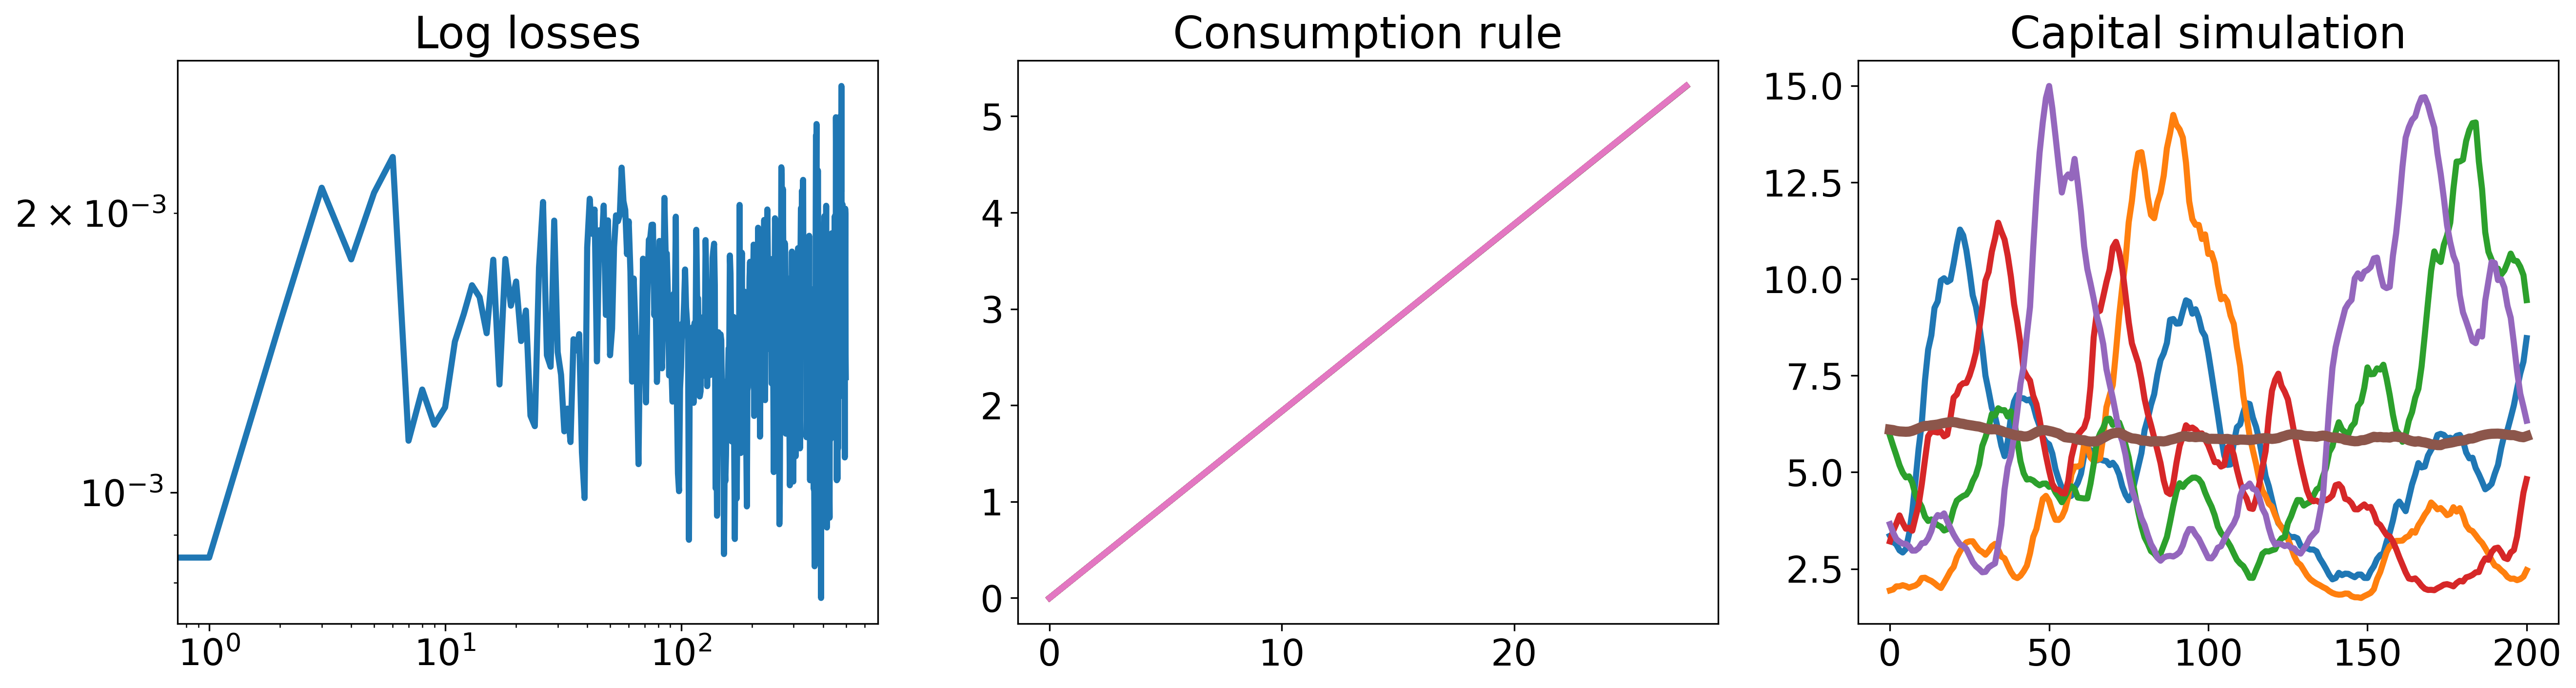

In [45]:
# Set plotting parameters 
plt.rcParams['agg.path.chunksize'] = 100000
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 18

# Columns and rows in graph
rows = 1
cols = 3
    
# Width, height automatically set
height = 5*rows
width = 7*cols

fig = plt.figure()
fig.set_figwidth(width)
fig.set_figheight(height)

# Plot Learning Losses
ax = plt.subplot(rows, cols, 1)
_ = plt.plot(loss_vals)
plt.yscale('log')
plt.xscale('log')
ax.title.set_text("Log losses")

counter = 2

ax = plt.subplot(rows, cols, 2)
for i in range(decision_rule_results["c0"].shape[1]):
    plt.plot(decision_rule_results["w0"][:, i, 0], decision_rule_results["c0"][:, i, 0])
ax.title.set_text("Consumption rule")

ax = plt.subplot(rows, cols, 3)
start = 200
end = 400
drawn_agents = 5
for i in range(min(5, simulation_results["k"].shape[2])):
    plt.plot(simulation_results["k"][start:end+1, 0, i]) # DRAW ONLY BATCH N = 0
if simulation_results["k"].shape[2] != 1: # Plot mean if more than one line was drawn
    plt.plot(np.mean(simulation_results["k"][start:end+1, 0], axis=1), linewidth=5.0) # DRAW ONLY BATCH N = 0
ax.title.set_text("Capital simulation")
# Classroom version: show the figure inline instead of saving to a local path.
plt.show()